In [1]:
from sklearn.linear_model import LinearRegression

# 1. 定义数据
# 自变量，每周学习时长
X = [[5], [8], [10], [12], [15], [3], [7], [9], [14], [6]]
# 因变量，数学考试成绩
y = [55, 65, 70, 75, 85, 50, 60, 72, 80, 58]

lr_model = LinearRegression()
lr_model.fit(X, y)
print(lr_model.coef_)
print(lr_model.intercept_)

[2.87070855]
41.45069393718042


In [2]:
# 预测
x_new = [[11]]
y_pred = lr_model.predict(x_new)
y_pred

array([73.02848795])

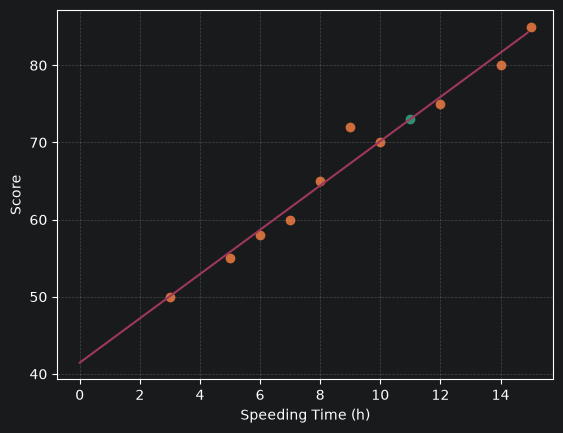

In [9]:
# 画图
import matplotlib.pyplot as plt
import numpy as np

line_x = np.arange(0, 15, 0.1).reshape(-1, 1)
line_y = lr_model.predict(line_x)

plt.scatter(x_new, y_pred, color="C3")
plt.scatter(X, y, color="C1")
plt.plot(line_x, line_y, color="C2")
plt.grid(True, linestyle="--", alpha=0.3)
plt.xlabel("Speeding Time (h)")
plt.ylabel("Score")
plt.show()

对于一元线性回归:

$$f(x_i) = \beta_0 + \beta_1 x_i$$

$$MSE = \frac{1}{n} \sum_{i=1}^n (\beta_0 + \beta_1 x_i - y_i)^2$$

利用求偏导、令偏导等于0的数学推导，可得：

$$\beta_1 = \frac{\sum_{i=1}^n (x_i - \overline{x})(y_i - \overline{y})}{\sum_{i=1}^n (x_i - \overline{x})^2}$$

$$\beta_0 = \overline{y} - \beta_1\overline{x}$$

其中 $\frac{1}{n}\sum_{i=1}^n (x_i - \overline{x})(y_i - \overline{y})$ 其实就是 $x$ 和 $y$ 的 **协方差**，API 调用为 `np.cov(x, y)`

In [10]:
# 可以在当前模型下验证：
cov = np.cov(np.array(X).T, y)
print(cov)
"""
     x        y
x  x的方差  xy协方差
y xy协方差   y的方差
"""

[[ 15.21111111  43.66666667]
 [ 43.66666667 128.66666667]]


In [13]:
beta1 = cov[0, 1] / cov[0 ,0]
beta0 = np.mean(y) - beta1 * np.mean(X)
print(lr_model.intercept_, lr_model.coef_)
print(beta0, beta1)

41.45069393718042 [2.87070855]
41.45069393718042 2.8707085463842223


In [ ]:
# 当一元线性回归不计算截距时，可以加速训练
# 适合特定特征的数据集
model = LinearRegression(fit_intercept=False)

对于多元线性回归
正规方程法（Normal Equation），基于 **最小二乘法** 通过求解矩阵方程来直接获得参数值
令：
$$MSE = \frac{1}{n}\sum_{i=1}^{n}(f(\mathbf{x_i}) - y_i)^2$$
$$= \frac{1}{n} (\mathbf{X}\boldsymbol{\beta} - \mathbf{y})^T (\mathbf{X}\boldsymbol{\beta} - \mathbf{y})$$

令导数矩阵 = 0，可求得

$$\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

当维度上来以后，矩阵的逆计算量会非常的大，因此，线性回归训练成本也会快速上涨